# 02. Khám phá dữ liệu (EDA)

**Học phần:** Khai thác dữ liệu — Nhóm 12

Notebook này phân tích phân phối, tương quan và ngoại lệ của sáu yếu tố cơ sở trên dữ liệu 5 năm,
làm cơ sở cho việc chọn cách chuẩn hóa dữ liệu ở notebook 03.

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

figures_dir = project_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Thống kê mô tả và độ lệch phân phối (Skewness)
Phân tích trung bình, độ lệch chuẩn, khoảng tứ phân vị và hệ số lệch của 6 đặc trưng chính.

In [3]:
df = pd.read_csv(project_root / 'data' / 'interim' / 'happiness_merged.csv')
feature_cols = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom', 'generosity', 'corruption_perception']

stats_summary = df[feature_cols].describe().T
stats_summary['skewness'] = df[feature_cols].skew()
stats_summary

,count,mean,std,min,25%,50%,75%,max,skewness
gdp_per_capita,782.0,0.916047,0.407340,0.0,0.606500,0.982205,1.236187,2.096000,-0.318581
social_support,782.0,1.078392,0.329548,0.0,0.869363,1.124735,1.327250,1.644000,-0.684632
healthy_life_expectancy,782.0,0.612416,0.248309,0.0,0.440183,0.647310,0.808000,1.141000,-0.501203
freedom,782.0,0.411091,0.152880,0.0,0.309768,0.431000,0.531000,0.724000,-0.521259
generosity,782.0,0.218576,0.122321,0.0,0.130000,0.201982,0.278832,0.838075,1.044360
corruption_perception,781.0,0.125436,0.105816,0.0,0.054000,0.091000,0.156030,0.551910,1.520888


## 2. Trực quan hóa hình dạng phân phối (Histograms & KDE)
Kiểm tra xem đặc trưng nào có phân phối chuẩn, đặc trưng nào bị lệch mạnh (ví dụ corruption perception thường bị lệch phải mạnh).

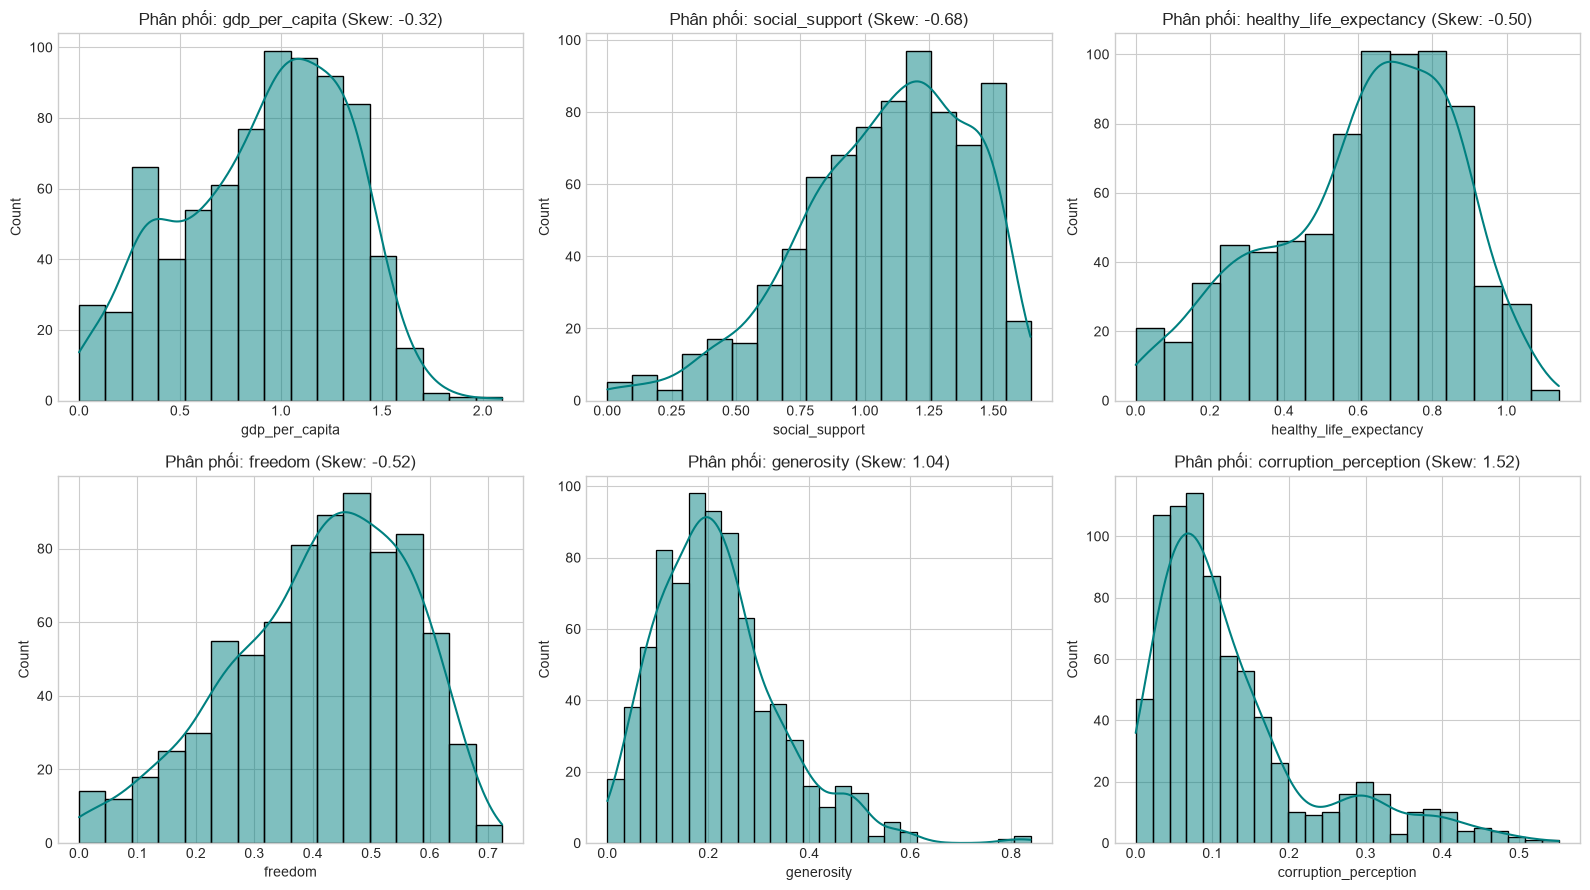

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Phân phối: {col} (Skew: {df[col].skew():.2f})')
plt.tight_layout()
plt.savefig(figures_dir / 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Phân tích tương quan giữa các đặc trưng và với Happiness Score
Đánh giá mức độ đa cộng tuyến (multicollinearity) và tương quan với điểm hạnh phúc thực tế.

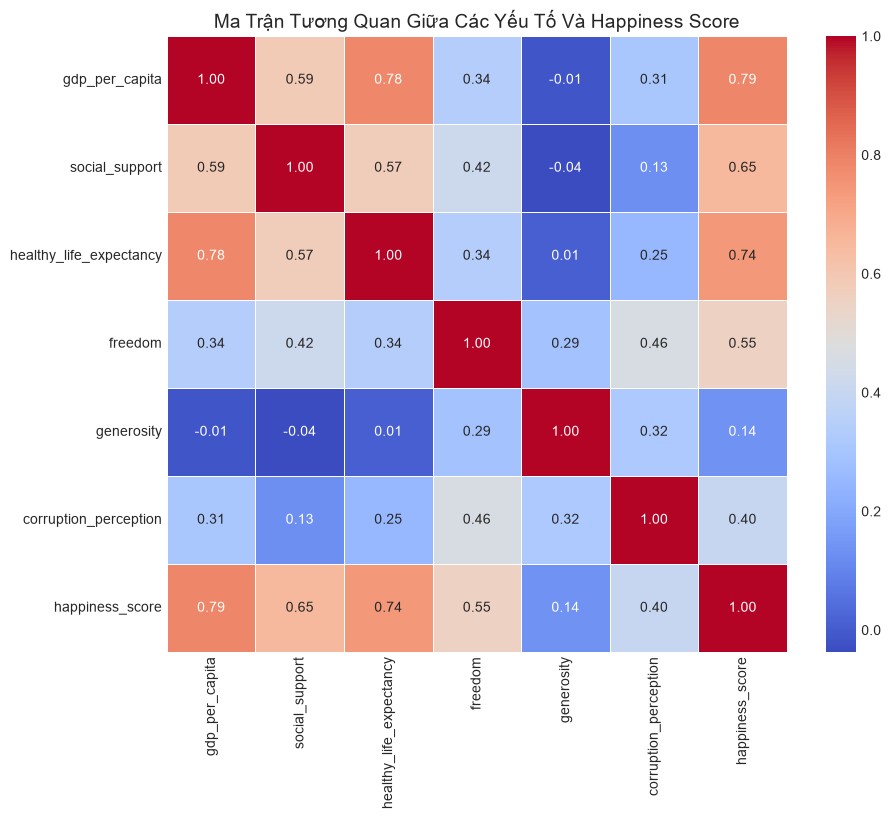

In [5]:
corr_cols = feature_cols + ['happiness_score']
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma Trận Tương Quan Giữa Các Yếu Tố Và Happiness Score', fontsize=14)
plt.savefig(figures_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Phát hiện và đánh giá ngoại lệ (Outlier Detection qua Boxplots)
Xác định các giá trị ngoại lệ để quyết định sử dụng `StandardScaler` hay `RobustScaler`.

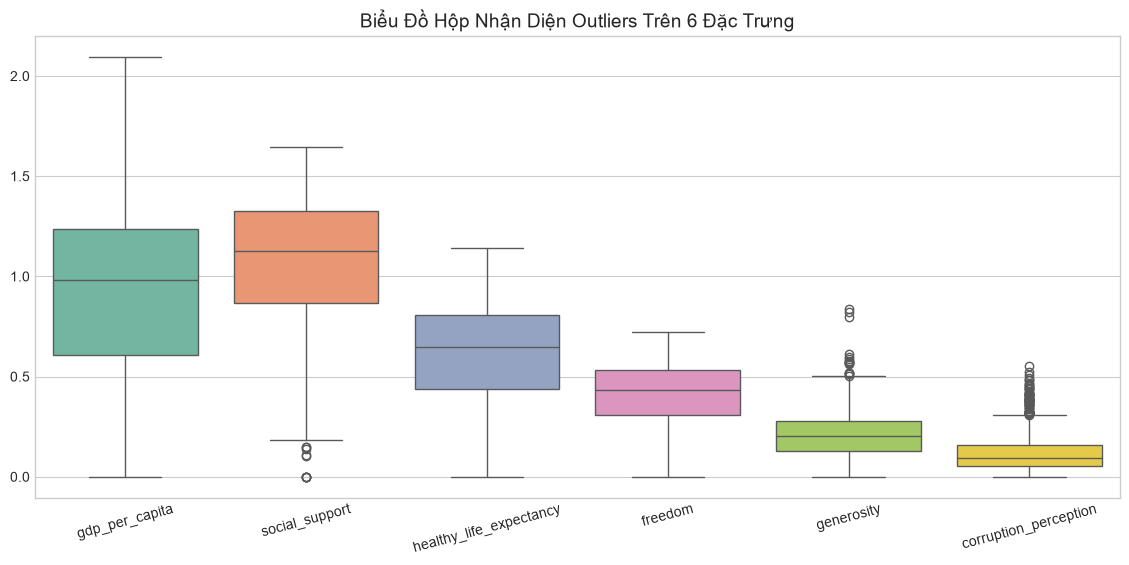

In [6]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[feature_cols], palette='Set2')
plt.title('Biểu Đồ Hộp Nhận Diện Outliers Trên 6 Đặc Trưng', fontsize=14)
plt.xticks(rotation=15)
plt.savefig(figures_dir / 'boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()